# YOLO11n Baseline on New Roboflow Data

Kaggle-ready validation notebook for the newly labeled `shrimpdisbd-tigershrimp_mrtudat` dataset.

The split is deliberately mixed because only part of the new export preserves the historical specimen filename convention:

- convention-matched files: disease-stratified grouped-specimen split
- unmatched files: label-stratified image-level random split
- final train/valid/test folders: merged from both branches

This is a protocol diagnostic first. Do not compare its metrics directly with the old dataset until the merged split manifest and naming coverage have been reviewed.


## Outputs to Preserve

Download or preserve these files after the run:

- `reports/seg_yolo11n_new_dataset_mixed_split_baseline_summary.csv`
- `reports/seg_yolo11n_new_dataset_mixed_split_baseline_paper_row.csv`
- `reports/seg_yolo11n_new_dataset_mixed_split_baseline_partial.csv`
- `reports/split_manifests/merged_mixed_split_seed42_manifest.csv`
- `reports/split_manifests/merged_mixed_split_seed42_summary.csv`
- `reports/split_manifests/merged_mixed_split_seed42_fingerprint.txt`
- the selected `runs/segment/.../weights/best.pt` checkpoint


## Run Controls

In [1]:
# Run controls
EXECUTION_PLAN = 'yolo11n_new_dataset_mixed_split_baseline'
SMOKE_RUN = False
SEEDS = [42]
ULTRALYTICS_VERSION = '8.4.62'

# This baseline preserves the paper-facing clean-light YOLO policy.
DISABLE_ULTRALYTICS_ALBUMENTATIONS = False
YOLO_MODELS = ['yolo11n-seg.pt']
INCLUDE_M_MODELS = False
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
ROBOFLOW_WORKSPACE = 'lets-try-this'
ROBOFLOW_PROJECT = 'shrimpdisbd-tigershrimp_mrtudat'
ROBOFLOW_VERSION = 1
ROBOFLOW_FORMAT = 'yolo26'
NAMING_CONVENTION = '<disease>-<shrimpid>-img-<number>'

print('EXECUTION_PLAN:', EXECUTION_PLAN)
print('SMOKE_RUN:', SMOKE_RUN)
print('SEEDS:', SEEDS)
print('YOLO_MODELS:', YOLO_MODELS)
print('Roboflow project:', f'{ROBOFLOW_WORKSPACE}/{ROBOFLOW_PROJECT}/v{ROBOFLOW_VERSION}')


EXECUTION_PLAN: yolo11n_new_dataset_mixed_split_baseline
SMOKE_RUN: False
SEEDS: [42]
YOLO_MODELS: ['yolo11n-seg.pt']
Roboflow project: lets-try-this/shrimpdisbd-tigershrimp_mrtudat/v1


## Dataset Download

In [2]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

if importlib.util.find_spec('roboflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'roboflow'])

from roboflow import Roboflow

ROBOFLOW_API_KEY_DIRECT = ''  # Keep empty. Use a Kaggle Secret named ROBOFLOW_API_KEY.

def get_roboflow_api_key():
    try:
        from kaggle_secrets import UserSecretsClient
        key = UserSecretsClient().get_secret('ROBOFLOW_API_KEY')
        if key:
            return key.strip()
    except Exception:
        pass
    if ROBOFLOW_API_KEY_DIRECT.strip():
        return ROBOFLOW_API_KEY_DIRECT.strip()
    return os.environ.get('ROBOFLOW_API_KEY', '').strip()

api_key = get_roboflow_api_key()
if not api_key:
    raise RuntimeError('Missing ROBOFLOW_API_KEY. Add it to Kaggle Secrets; do not paste it into the notebook.')

rf = Roboflow(api_key=api_key)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download(ROBOFLOW_FORMAT)
DATASET_LOCATION = Path(dataset.location)
print('Downloaded dataset location:', DATASET_LOCATION)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 108.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ShrimpDisBD-TigerShrimp_MrTuDat-1 in yolo26:: 100%|██████████| 2907/2907 [00:00<00:00, 3935.84it/s]

Downloaded dataset location: /kaggle/working/ShrimpDisBD-TigerShrimp_MrTuDat-1


## Leakage-Safe Split Helpers

In [3]:
## Mixed split: grouped for convention-matched names, stratified random for unmatched names

import hashlib
import os
import random
import re
import shutil
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import yaml

SEED = 42
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

DATASET_DIR = Path(DATASET_LOCATION)
if not (DATASET_DIR / 'data.yaml').exists():
    yaml_candidates = sorted(DATASET_DIR.rglob('data.yaml'))
    if not yaml_candidates:
        raise FileNotFoundError(f'No data.yaml found below {DATASET_DIR}')
    DATASET_DIR = yaml_candidates[0].parent
base_path = DATASET_DIR
data_yaml_path = DATASET_DIR / 'data.yaml'

SHRIMP_NAME_PATTERN = re.compile(
    r'^(?P<disease>Healthy|BG|WSSV_BG|WSSV)-(?P<shrimp_id>.+)-img-(?P<img_num>\d+)$',
    re.IGNORECASE,
)

yaml_content = yaml.safe_load(data_yaml_path.read_text(encoding='utf-8')) or {}
raw_names = yaml_content.get('names', {})
if isinstance(raw_names, list):
    CLASS_NAMES = {i: str(name) for i, name in enumerate(raw_names)}
else:
    CLASS_NAMES = {int(k): str(v) for k, v in raw_names.items()}

def normalize_roboflow_stem(stem):
    stem = re.sub(r'_(jpg|jpeg|png|bmp|webp)\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)
    return re.sub(r'\.rf\.[0-9a-f]+$', '', stem, flags=re.IGNORECASE)

def parse_shrimp_group_key(image_name):
    stem = normalize_roboflow_stem(Path(image_name).stem)
    match = SHRIMP_NAME_PATTERN.match(stem)
    if not match:
        return None, 'unparsed', None, None
    disease = match.group('disease')
    shrimp_id = match.group('shrimp_id')
    return f'{disease.lower()}::{shrimp_id}', disease, shrimp_id, int(match.group('img_num'))

def image_files_in_split(split):
    directory = base_path / split / 'images'
    if not directory.exists():
        return []
    return sorted(p for p in directory.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

def label_path_for_image(image_path):
    path = image_path.parent.parent / 'labels' / f'{image_path.stem}.txt'
    if path.exists():
        return path
    matches = sorted((image_path.parent.parent / 'labels').glob(f'{image_path.stem}*.txt'))
    return matches[0] if matches else path

def move_image_and_label(image_path, target_split):
    image_dst = base_path / target_split / 'images' / image_path.name
    label_src = label_path_for_image(image_path)
    label_dst = base_path / target_split / 'labels' / f'{image_path.stem}.txt'
    image_dst.parent.mkdir(parents=True, exist_ok=True)
    label_dst.parent.mkdir(parents=True, exist_ok=True)
    if image_path.resolve() != image_dst.resolve():
        if image_dst.exists():
            raise FileExistsError(f'Duplicate image destination: {image_dst}')
        shutil.move(str(image_path), str(image_dst))
    if label_src.exists() and label_src.resolve() != label_dst.resolve():
        if label_dst.exists():
            raise FileExistsError(f'Duplicate label destination: {label_dst}')
        shutil.move(str(label_src), str(label_dst))
    elif not label_dst.exists():
        label_dst.write_text('', encoding='utf-8')

def rebuild_train_pool_from_all_splits():
    all_images = []
    for split in ['train', 'valid', 'test']:
        all_images.extend(image_files_in_split(split))
    for image_path in all_images:
        move_image_and_label(image_path, 'train')
    return image_files_in_split('train')

def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()

def image_class_ids(image_path):
    label_path = label_path_for_image(image_path)
    ids = []
    if label_path.exists():
        for line in label_path.read_text(encoding='utf-8').splitlines():
            parts = line.strip().split()
            if parts:
                ids.append(int(float(parts[0])))
    return sorted(set(ids))

def disease_stratum_for_image(image_path):
    ids = image_class_ids(image_path)
    if not ids:
        return 'healthy_empty'
    names = [CLASS_NAMES.get(i, f'class_{i}') for i in ids]
    return '+'.join(name.strip().lower().replace(' ', '_') for name in names)

def split_one_stratum(items, seed, rng=None):
    items = list(items)
    (rng or random.Random(seed)).shuffle(items)
    n = len(items)
    n_train = int(TRAIN_RATIO * n)
    n_valid = int(VAL_RATIO * n)
    if n >= 3:
        n_valid = max(1, n_valid)
        n_train = max(1, n_train)
        if n_train + n_valid >= n:
            n_train = max(1, n - n_valid - 1)
    return {
        'train': items[:n_train],
        'valid': items[n_train:n_train + n_valid],
        'test': items[n_train + n_valid:],
    }

def split_grouped_items(group_items, seed):
    by_stratum = defaultdict(list)
    for group_key, filenames, stratum in group_items:
        by_stratum[stratum].append((group_key, filenames, stratum))
    out = {'train': [], 'valid': [], 'test': []}
    rng = random.Random(seed)
    for stratum, items in sorted(by_stratum.items()):
        pieces = split_one_stratum(sorted(items, key=lambda x: x[0]), seed + 11, rng=rng)
        for split, values in pieces.items():
            out[split].extend(values)
        print(f'Grouped branch {stratum}: {len(pieces["train"])} train groups, {len(pieces["valid"])} valid groups, {len(pieces["test"])} test groups')
    return out

def split_random_items(image_paths, seed):
    by_stratum = defaultdict(list)
    for path in image_paths:
        by_stratum[disease_stratum_for_image(path)].append(path.name)
    out = {'train': [], 'valid': [], 'test': []}
    for stratum, items in sorted(by_stratum.items()):
        pieces = split_one_stratum(sorted(items), seed + 29)
        for split, values in pieces.items():
            out[split].extend(values)
        print(f'Unmatched branch {stratum}: {len(pieces["train"])} train images, {len(pieces["valid"])} valid images, {len(pieces["test"])} test images')
    return out

def mixed_split(seed=42):
    image_paths = rebuild_train_pool_from_all_splits()
    convention_groups = defaultdict(list)
    unmatched = []
    source_meta = {}
    for path in image_paths:
        group_key, filename_disease, shrimp_id, img_num = parse_shrimp_group_key(path.name)
        if group_key is None:
            unmatched.append(path)
            source_meta[path.name] = {'source_subset': 'unmatched_stratified_random', 'naming_convention_matched': False, 'parsed_group_key': f'unparsed::{path.stem}', 'filename_disease': 'unparsed'}
        else:
            convention_groups[group_key].append(path.name)
            source_meta[path.name] = {'source_subset': 'convention_grouped_stratified', 'naming_convention_matched': True, 'parsed_group_key': group_key, 'filename_disease': filename_disease}

    grouped_items = []
    for group_key, filenames in convention_groups.items():
        # Preserve the original baseline's filename-disease stratification for recognized groups.
        strata = Counter(str(source_meta[name]['filename_disease']).lower() for name in filenames)
        grouped_items.append((group_key, sorted(filenames), strata.most_common(1)[0][0]))

    grouped_splits = split_grouped_items(grouped_items, seed)
    random_splits = split_random_items(unmatched, seed)
    assignments = {}
    for branch_splits in [grouped_splits, random_splits]:
        for split, items in branch_splits.items():
            values = items
            if values and isinstance(values[0], tuple):
                names = [name for _, filenames, _ in values for name in filenames]
            else:
                names = values
            for name in names:
                if name in assignments:
                    raise RuntimeError(f'Image assigned twice: {name}')
                assignments[name] = split

    if len(assignments) != len(image_paths):
        missing = sorted({p.name for p in image_paths} - set(assignments))
        raise RuntimeError(f'Mixed split did not assign every image. Missing: {missing[:10]}')

    for name, split in assignments.items():
        move_image_and_label(base_path / 'train' / 'images' / name, split)
    remove_yolo_label_caches(base_path)

    global SOURCE_META
    SOURCE_META = source_meta
    print(f'Mixed split complete: {len(convention_groups)} convention groups and {len(unmatched)} unmatched images.')
    print('Merged image counts:', {split: len(image_files_in_split(split)) for split in ['train', 'valid', 'test']})
    return assignments

mixed_split(SEED)


Grouped branch bg: 60 train groups, 7 valid groups, 8 test groups
Grouped branch healthy: 113 train groups, 14 valid groups, 15 test groups
Grouped branch wssv: 94 train groups, 11 valid groups, 13 test groups
Grouped branch wssv_bg: 64 train groups, 8 valid groups, 9 test groups
Unmatched branch bg: 119 train images, 14 valid images, 16 test images
Unmatched branch wssv: 123 train images, 15 valid images, 16 test images
Mixed split complete: 416 convention groups and 303 unmatched images.
Merged image counts: {'train': 1147, 'valid': 144, 'test': 161}


{'BG-51-img-1_jpg.rf.ab196d3274ca53f501aa01972a80d4b2.jpg': 'train',
 'BG-51-img-2_jpg.rf.984c46ab6c044e729ef8ee144bef1037.jpg': 'train',
 'BG-51-img-3_jpg.rf.507cfbcb2a97773ceb225f6b1023e0f6.jpg': 'train',
 'BG-26-img-1_jpg.rf.34d5894d8b4c7d4a405963feab300987.jpg': 'train',
 'BG-42-img-1_jpg.rf.c52e28870b2a1f684771f67d7ffa4427.jpg': 'train',
 'BG-42-img-2_jpg.rf.8e16065a22ea5ca238942dd5e4151197.jpg': 'train',
 'BG-42-img-3_jpg.rf.1cbf745950cea8c9fa071148d52f4199.jpg': 'train',
 'BG-17-img-1_jpg.rf.555cc18b1e36a00d2fa7ff31c64abec6.jpg': 'train',
 'BG-16-img-1_jpg.rf.dbb2f24dcb0882662092e3f5d973a958.jpg': 'train',
 'BG-63-img-1_jpg.rf.bf5fd1d841652dcea4180f6d292b4216.jpg': 'train',
 'BG-63-img-2_jpg.rf.89f5330ec9c7873c78a951c0ab6fb264.jpg': 'train',
 'BG-74-img-1_jpg.rf.e58c38b24189a322f2d062e4b8e764ab.jpg': 'train',
 'BG-74-img-2_jpg.rf.4debf3b9b359e59c69d4da18fd755eb7.jpg': 'train',
 'BG-74-img-3_jpg.rf.d89ea9fca1896c60e4dfa3295618842e.jpg': 'train',
 'BG-64-img-1_jpg.rf.750197c06db70

In [4]:
import importlib.util
import subprocess
import sys

def ensure_ultralytics_version(version):
    installed = None
    if importlib.util.find_spec('ultralytics') is not None:
        try:
            import ultralytics
            installed = getattr(ultralytics, '__version__', None)
        except Exception:
            installed = None
    if installed != version:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', f'ultralytics=={version}'])
        print(f'Installed Ultralytics {version} for baseline compatibility.')
    else:
        print(f'Ultralytics {version} already installed.')

ensure_ultralytics_version(ULTRALYTICS_VERSION)

from ultralytics import YOLO
import os
from pathlib import Path

# Preserve the dynamically discovered Roboflow dataset path from the split cell.
base_path = Path(base_path)
data_yaml_path = Path(data_yaml_path)

# Baseline model is defined in the run-control cell. Keep this smoke check
# synchronized with the paper-facing one-row baseline configuration.
YOLO_MODEL = YOLO_MODELS[0]
MODEL_STEM = Path(YOLO_MODEL).stem
RUN_BASE_NAME = f'{MODEL_STEM}_shrimp_seg_merged_convention_grouped_plus_unmatched_stratified_random'

# Load once here as a smoke check. Training cells instantiate fresh models per experiment.
model = YOLO(YOLO_MODEL)
print('Configured baseline segmentation model:')
for configured_model in YOLO_MODELS:
    print(f'  - {configured_model}')
print(f'Run name prefix: {RUN_BASE_NAME}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.7 MB/s eta 0:00:00
Installed Ultralytics 8.4.62 for baseline compatibility.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Configured baseline segmentation model:
  - yolo11n-seg.pt
Run name prefix: yolo11n-seg_shrimp_seg_merged_convention_grouped_plus_unmatched_stratified_random


In [5]:
import yaml

content = yaml.safe_load(data_yaml_path.read_text(encoding='utf-8'))
content['train'] = str(base_path / 'train' / 'images')
content['val'] = str(base_path / 'valid' / 'images')
content['test'] = str(base_path / 'test' / 'images')
data_yaml_path.write_text(yaml.safe_dump(content, sort_keys=False), encoding='utf-8')
print('data.yaml updated:', data_yaml_path)


data.yaml updated: /kaggle/working/ShrimpDisBD-TigerShrimp_MrTuDat-1/data.yaml


### Exploratory Data Analysis (EDA)
We will analyze the dataset to understand the class distribution and visualize some sample images with their masks.

In [6]:
import os
import yaml
import matplotlib.pyplot as plt
import cv2
import numpy as np
from collections import Counter
from pathlib import Path

# Load class names from data.yaml. Empty label files are healthy shrimp negatives.
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
HEALTHY_CLASS_NAME = 'healthy'
print(f"Disease mask classes found: {class_names}")
print(f"Empty label files will be treated as: {HEALTHY_CLASS_NAME} shrimp negatives")


def split_label_stats(label_dir):
    instance_counts = Counter()
    labeled_images = 0
    healthy_images = 0
    missing_or_empty = 0
    label_dir = Path(label_dir)
    for label_file in label_dir.glob('*.txt'):
        lines = [line.strip() for line in label_file.read_text().splitlines() if line.strip()]
        if not lines:
            healthy_images += 1
            continue
        labeled_images += 1
        for line in lines:
            class_id = int(float(line.split()[0]))
            instance_counts[class_id] += 1
    return {
        'instance_counts': instance_counts,
        'labeled_images': labeled_images,
        'healthy_images': healthy_images,
        'total_label_files': labeled_images + healthy_images,
    }


stats = {}
for split in ['train', 'valid', 'test']:
    label_dir = os.path.join(base_path, split, 'labels')
    stats[split] = split_label_stats(label_dir)

for split, split_stats in stats.items():
    print(f"\n{split.capitalize()} Split:")
    print(f"  - labeled disease images: {split_stats['labeled_images']}")
    print(f"  - healthy negative images: {split_stats['healthy_images']}")
    for cid, count in split_stats['instance_counts'].items():
        name = class_names[cid] if cid < len(class_names) else f"Unknown({cid})"
        print(f"  - {name}: {count} mask instances")

Disease mask classes found: ['BG', 'WSSV']
Empty label files will be treated as: healthy shrimp negatives

Train Split:
  - labeled disease images: 826
  - healthy negative images: 321
  - WSSV: 582 mask instances
  - BG: 548 mask instances

Valid Split:
  - labeled disease images: 103
  - healthy negative images: 41
  - BG: 61 mask instances
  - WSSV: 71 mask instances

Test Split:
  - labeled disease images: 120
  - healthy negative images: 41
  - WSSV: 84 mask instances
  - BG: 71 mask instances


### Visualizing Class Imbalance
An imbalanced dataset can cause the model to be biased. Let's visualize the distribution across our splits.

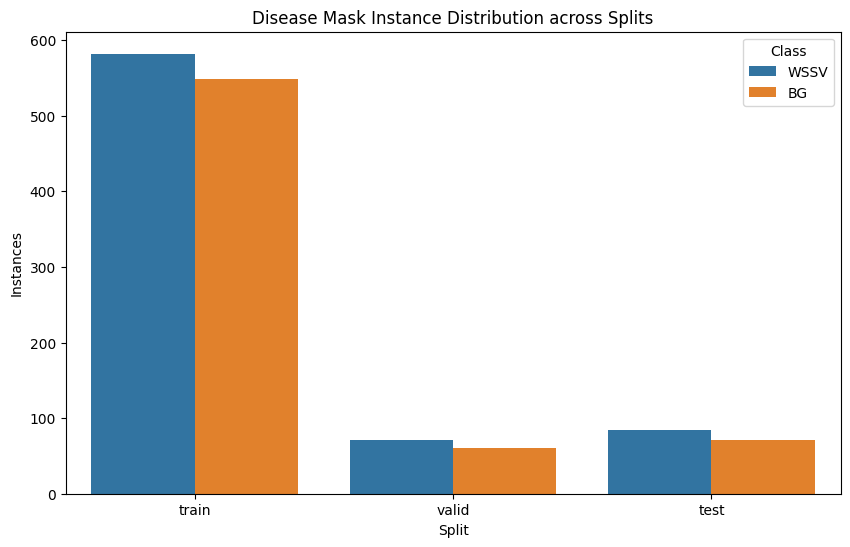

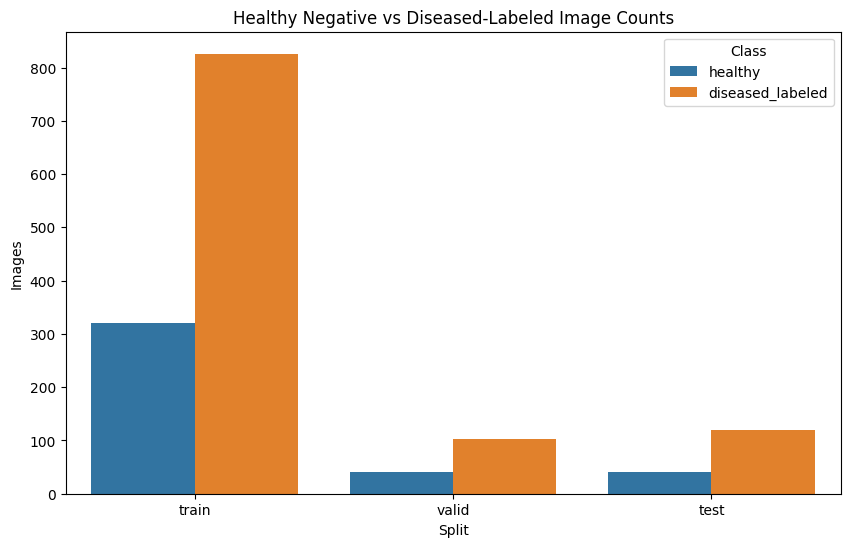

Train: 48.50% blackgill instances; 27.99% healthy negative images
Valid: 46.21% blackgill instances; 28.47% healthy negative images
Test: 45.81% blackgill instances; 25.47% healthy negative images


In [7]:
import pandas as pd
import seaborn as sns

instance_plot_data = []
image_plot_data = []
for split, split_stats in stats.items():
    image_plot_data.append({'Split': split, 'Class': HEALTHY_CLASS_NAME, 'Images': split_stats['healthy_images']})
    image_plot_data.append({'Split': split, 'Class': 'diseased_labeled', 'Images': split_stats['labeled_images']})
    for cid, count in split_stats['instance_counts'].items():
        instance_plot_data.append({'Split': split, 'Class': class_names[cid], 'Instances': count})

if instance_plot_data:
    df_instances = pd.DataFrame(instance_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_instances, x='Split', y='Instances', hue='Class')
    plt.title('Disease Mask Instance Distribution across Splits')
    plt.show()

if image_plot_data:
    df_images = pd.DataFrame(image_plot_data)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_images, x='Split', y='Images', hue='Class')
    plt.title('Healthy Negative vs Diseased-Labeled Image Counts')
    plt.show()

for split, split_stats in stats.items():
    total_instances = sum(split_stats['instance_counts'].values())
    blackgill_ratio = (split_stats['instance_counts'].get(0, 0) / max(1, total_instances)) * 100
    healthy_ratio = (split_stats['healthy_images'] / max(1, split_stats['total_label_files'])) * 100
    print(f"{split.capitalize()}: {blackgill_ratio:.2f}% blackgill instances; {healthy_ratio:.2f}% healthy negative images")

#### Observations:
1. **High Disease-Class Imbalance**: `blackgill` is a small fraction of disease mask instances.
2. **Healthy Negatives Are Real Data**: Empty label files are healthy shrimp images, not missing annotations.
3. **Evaluation Must Split Responsibilities**:
   - Diseased/labeled images should be evaluated with box/mask mAP and recall.
   - Healthy/empty-label images should be evaluated with false-positive rate and false-positive masks per image.

**Recommendation**: Keep healthy images in training as negative controls, but report healthy false-positive metrics separately instead of mixing them into disease mask mAP interpretation.

### Optional Minority RandAugment Oversampling
The baseline starts with `ENABLE_MINORITY_OVERSAMPLING = False`. Turn it on later to create RandAugment-based minority samples. The implementation uses label-preserving photometric RandAugment operations so segmentation polygons remain valid.


In [8]:
import cv2
import os
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps

IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

ENABLE_MINORITY_OVERSAMPLING = False
MINORITY_CLASS_ID = 0
MINORITY_OVERSAMPLING_MULTIPLIER = 8
RAND_AUGMENT_NUM_OPS = 2
RAND_AUGMENT_MAGNITUDE = 9
RAND_AUGMENT_MAX_MAGNITUDE = 30

# Geometric RandAugment ops are intentionally excluded here because this is
# segmentation data. Photometric ops preserve the existing polygon labels.
RAND_AUGMENT_OPS = [
    'autocontrast',
    'equalize',
    'solarize',
    'posterize',
    'color',
    'contrast',
    'brightness',
    'sharpness',
]


def find_image_for_label(image_dir, label_file):
    stem = Path(label_file).stem
    for ext in IMAGE_EXTENSIONS:
        candidate = Path(image_dir) / f'{stem}{ext}'
        if candidate.exists():
            return candidate
    return None


def remove_yolo_label_caches(base_path):
    for cache_path in Path(base_path).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
        else:
            healthy += 1
    return labeled, healthy


def randaugment_level(max_value, signed=False):
    magnitude = RAND_AUGMENT_MAGNITUDE / RAND_AUGMENT_MAX_MAGNITUDE
    value = magnitude * max_value
    if signed and random.random() < 0.5:
        value *= -1
    return value


def apply_randaugment_op(image, op_name):
    if op_name == 'autocontrast':
        return ImageOps.autocontrast(image)
    if op_name == 'equalize':
        return ImageOps.equalize(image)
    if op_name == 'solarize':
        threshold = int(256 - randaugment_level(256))
        return ImageOps.solarize(image, threshold=max(0, min(256, threshold)))
    if op_name == 'posterize':
        bits = int(round(8 - randaugment_level(4)))
        return ImageOps.posterize(image, bits=max(4, min(8, bits)))
    if op_name == 'color':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Color(image).enhance(max(0.1, factor))
    if op_name == 'contrast':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Contrast(image).enhance(max(0.1, factor))
    if op_name == 'brightness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Brightness(image).enhance(max(0.1, factor))
    if op_name == 'sharpness':
        factor = 1.0 + randaugment_level(0.9, signed=True)
        return ImageEnhance.Sharpness(image).enhance(max(0.1, factor))
    raise ValueError(f'Unsupported RandAugment op: {op_name}')


def apply_label_preserving_randaugment(image):
    image = image.convert('RGB')
    ops = random.choices(RAND_AUGMENT_OPS, k=RAND_AUGMENT_NUM_OPS)
    for op_name in ops:
        image = apply_randaugment_op(image, op_name)
    return image


def augment_minority_class(base_path, class_id_to_target=0, multiplier=5):
    train_img_dir = os.path.join(base_path, 'train', 'images')
    train_lbl_dir = os.path.join(base_path, 'train', 'labels')

    label_files = [f for f in os.listdir(train_lbl_dir) if f.endswith('.txt')]
    augmented_count = 0
    skipped_count = 0
    random.seed(SEED)

    for label_file in label_files:
        if label_file.startswith('randaug_'):
            continue

        label_path = os.path.join(train_lbl_dir, label_file)
        with open(label_path, 'r') as f:
            content = [line.strip() for line in f.readlines() if line.strip()]

        has_target = any(int(line.split()[0]) == class_id_to_target for line in content)
        if not has_target:
            continue

        img_path = find_image_for_label(train_img_dir, label_file)
        if img_path is None:
            skipped_count += 1
            continue

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            skipped_count += 1
            continue

        for m in range(multiplier):
            aug_img = apply_label_preserving_randaugment(image)
            aug_image_name = f'randaug_{m}_{img_path.stem}.jpg'
            aug_label_name = f'randaug_{m}_{Path(label_file).stem}.txt'
            aug_img.save(os.path.join(train_img_dir, aug_image_name), quality=95)
            with open(os.path.join(train_lbl_dir, aug_label_name), 'w') as f:
                f.write('\n'.join(content) + '\n')
            augmented_count += 1

    remove_yolo_label_caches(base_path)
    labeled, healthy = count_labeled_images(train_lbl_dir)
    target_name = class_names[class_id_to_target] if class_id_to_target < len(class_names) else str(class_id_to_target)
    print(f'Created {augmented_count} RandAugment samples for class {target_name}.')
    print(f'Skipped {skipped_count} source labels due to missing image or invalid labels.')
    print(f'Train labels after augmentation: {labeled} diseased/labeled images, {healthy} healthy negative label files.')


if ENABLE_MINORITY_OVERSAMPLING:
    augment_minority_class(base_path, class_id_to_target=MINORITY_CLASS_ID, multiplier=MINORITY_OVERSAMPLING_MULTIPLIER)
else:
    print('Minority RandAugment oversampling disabled for the clean baseline.')


Minority RandAugment oversampling disabled for the clean baseline.


## Training Helpers

The following helpers are inherited from the grouped model-sweep notebook. They define the clean-light YOLO augmentation policy, control the default Ultralytics Albumentations hook, build labeled-only and healthy-only evaluation datasets, and compute healthy-aware metrics.


## Training and Evaluation Helpers

In [9]:
import csv
import gc
import math
import shutil
import time
from pathlib import Path

import cv2
import pandas as pd
import yaml
from IPython.display import display

EXPERIMENT_ROOT = Path('/kaggle/working/shrimp_yolo11n_new_dataset_mixed_split_baseline')
RUNS_DIR = Path('/kaggle/working/runs/segment')
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_RUN = bool(globals().get('SMOKE_RUN', False))
TRAIN_IMGSZ = 320 if SMOKE_RUN else 640
TRAIN_EPOCHS = 1 if SMOKE_RUN else 100
TRAIN_BATCH = 8 if SMOKE_RUN else 16
TRAIN_PATIENCE = 1 if SMOKE_RUN else 30
RUN_TEST_EVALUATION = not SMOKE_RUN

COUNT_PENALTY_WEIGHT = 0.05
DISEASE_MISS_PENALTY_WEIGHT = 0.15
HEALTHY_FP_PENALTY_WEIGHT = 0.10
PREDICT_CONF_FOR_COUNT = 0.25

EXPERIMENTS = [
    {
        'key': 'clean_light_aug_baseline',
        'name': 'Clean Baseline - Grouped Stratified Light YOLO Augmentation',
        'apply_clahe': False,
    },
]

CLEAN_LIGHT_AUG_TRAIN_ARGS = {
    # Main clean baseline: explicit light YOLO augmentation for regularization.
    # Mosaic, mixup, copy-paste, and erasing stay disabled. The hidden Ultralytics
    # Albumentations hook is controlled by DISABLE_ULTRALYTICS_ALBUMENTATIONS.
    'auto_augment': None,
    'erasing': 0.0,
    'mosaic': 0.0,
    'mixup': 0.0,
    'cutmix': 0.0,
    'copy_paste': 0.0,
    'fliplr': 0.5,
    'flipud': 0.0,
    'hsv_h': 0.01,
    'hsv_s': 0.35,
    'hsv_v': 0.20,
    'degrees': 0.0,
    'translate': 0.05,
    'scale': 0.20,
    'shear': 0.0,
    'perspective': 0.0,
    'multi_scale': 0.0,
    'bgr': 0.0,
}


def configure_ultralytics_albumentations_hook(disable=False):
    """Disable or restore Ultralytics' default Albumentations hook for this run."""
    try:
        import importlib
        import ultralytics.data.augment as yolo_augment
    except Exception as exc:
        print(f'Could not access Ultralytics Albumentations hook: {exc}')
        return

    if not disable:
        # Important in notebooks: a previous cell/run may already have monkey-patched
        # Albumentations. Reloading restores the original Ultralytics class.
        importlib.reload(yolo_augment)
        print('Ultralytics Albumentations hook enabled/restored for this run.')
        return

    class NoOpAlbumentations:
        contains_spatial = False

        def __init__(self, *args, **kwargs):
            self.transform = None

        def __call__(self, labels):
            return labels

    yolo_augment.Albumentations = NoOpAlbumentations
    print('Ultralytics Albumentations hook disabled for this run.')


def remove_yolo_label_caches(root):
    for cache_path in Path(root).glob('**/*.cache'):
        cache_path.unlink()
        print(f'Removed stale cache: {cache_path}')


def apply_clahe_to_dataset(image_dir):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(Path(image_dir).glob(f'*{ext}'))

    print(f'Applying CLAHE to {len(image_files)} images in {image_dir}...')
    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l2 = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)
        cv2.imwrite(str(img_path), enhanced)


def count_labeled_images(label_dir):
    labeled = 0
    healthy = 0
    instances = 0
    for label_path in Path(label_dir).glob('*.txt'):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        if lines:
            labeled += 1
            instances += len(lines)
        else:
            healthy += 1
    return {'labeled_images': labeled, 'healthy_images': healthy, 'instances': instances}


def write_data_yaml(dataset_dir, yaml_path, val_dir='valid', test_dir='test'):
    with open(data_yaml_path, 'r') as f:
        content = yaml.safe_load(f)
    content['train'] = str(Path(dataset_dir) / 'train' / 'images')
    content['val'] = str(Path(dataset_dir) / val_dir / 'images')
    content['test'] = str(Path(dataset_dir) / test_dir / 'images')
    with open(yaml_path, 'w') as f:
        yaml.safe_dump(content, f, sort_keys=False)
    return yaml_path


def copy_dataset_for_experiment(exp_key):
    src = Path(base_path)
    dst = EXPERIMENT_ROOT / exp_key / 'dataset'
    if dst.exists():
        shutil.rmtree(dst)
    ignore = shutil.ignore_patterns('runs', '*.cache', '.clahe_applied')
    shutil.copytree(src, dst, ignore=ignore)
    remove_yolo_label_caches(dst)
    return dst


def copy_split_by_label_state(src_dataset, dst_dataset, split, want_labeled):
    src_images = Path(src_dataset) / split / 'images'
    src_labels = Path(src_dataset) / split / 'labels'
    dst_images = Path(dst_dataset) / split / 'images'
    dst_labels = Path(dst_dataset) / split / 'labels'
    dst_images.mkdir(parents=True, exist_ok=True)
    dst_labels.mkdir(parents=True, exist_ok=True)

    copied = 0
    for label_path in sorted(src_labels.glob('*.txt')):
        lines = [line.strip() for line in label_path.read_text().splitlines() if line.strip()]
        is_labeled = bool(lines)
        if is_labeled != want_labeled:
            continue
        image_path = find_image_for_label(src_images, label_path.name)
        if image_path is None:
            continue
        shutil.copy2(image_path, dst_images / image_path.name)
        shutil.copy2(label_path, dst_labels / label_path.name)
        copied += 1
    return copied


def make_state_eval_dataset(src_dataset, exp_key, state_name, want_labeled):
    dst = EXPERIMENT_ROOT / exp_key / f'dataset_{state_name}_eval'
    if dst.exists():
        shutil.rmtree(dst)

    for sub in ['images', 'labels']:
        (dst / 'train' / sub).mkdir(parents=True, exist_ok=True)
    copied = {}
    for split in ['valid', 'test']:
        copied[split] = copy_split_by_label_state(src_dataset, dst, split, want_labeled=want_labeled)
    yaml_path = dst / f'data_{state_name}.yaml'
    write_data_yaml(dst, yaml_path)
    print(f'{state_name} eval dataset for {exp_key}: {copied}')
    return dst, yaml_path, copied


def make_labeled_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'labeled_only', want_labeled=True)


def make_healthy_only_eval_dataset(src_dataset, exp_key):
    return make_state_eval_dataset(src_dataset, exp_key, 'healthy_only', want_labeled=False)


def metric_value(metrics, dotted_path, default=float('nan')):
    obj = metrics
    for part in dotted_path.split('.'):
        if not hasattr(obj, part):
            return default
        obj = getattr(obj, part)
    try:
        return float(obj)
    except Exception:
        return default


def count_prediction_errors(model, images_dir, labels_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'images': 0,
            'gt_total': 0,
            'pred_box_total': 0,
            'pred_mask_total': 0,
            'box_count_mae': float('nan'),
            'mask_count_mae': float('nan'),
            'box_count_exact': float('nan'),
            'mask_count_exact': float('nan'),
            'disease_images': 0,
            'disease_box_miss_images': 0,
            'disease_mask_miss_images': 0,
            'disease_box_miss_rate': float('nan'),
            'disease_mask_miss_rate': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    box_errors = []
    mask_errors = []
    box_exact = []
    mask_exact = []
    gt_total = 0
    pred_box_total = 0
    pred_mask_total = 0
    disease_images = 0
    disease_box_miss_images = 0
    disease_mask_miss_images = 0

    for image_path, result in zip(image_paths, results):
        label_path = Path(labels_dir) / f'{image_path.stem}.txt'
        gt_count = 0
        if label_path.exists():
            gt_count = len([line for line in label_path.read_text().splitlines() if line.strip()])
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        denom = max(1, gt_count)
        box_errors.append(abs(box_count - gt_count) / denom)
        mask_errors.append(abs(mask_count - gt_count) / denom)
        box_exact.append(float(box_count == gt_count))
        mask_exact.append(float(mask_count == gt_count))
        if gt_count > 0:
            disease_images += 1
            disease_box_miss_images += int(box_count == 0)
            disease_mask_miss_images += int(mask_count == 0)
        gt_total += gt_count
        pred_box_total += box_count
        pred_mask_total += mask_count

    disease_box_miss_rate = disease_box_miss_images / disease_images if disease_images else float('nan')
    disease_mask_miss_rate = disease_mask_miss_images / disease_images if disease_images else float('nan')
    return {
        'images': len(image_paths),
        'gt_total': gt_total,
        'pred_box_total': pred_box_total,
        'pred_mask_total': pred_mask_total,
        'box_count_mae': sum(box_errors) / len(box_errors),
        'mask_count_mae': sum(mask_errors) / len(mask_errors),
        'box_count_exact': sum(box_exact) / len(box_exact),
        'mask_count_exact': sum(mask_exact) / len(mask_exact),
        'disease_images': disease_images,
        'disease_box_miss_images': disease_box_miss_images,
        'disease_mask_miss_images': disease_mask_miss_images,
        'disease_box_miss_rate': disease_box_miss_rate,
        'disease_mask_miss_rate': disease_mask_miss_rate,
    }


def healthy_false_positive_summary(model, images_dir, conf=PREDICT_CONF_FOR_COUNT):
    image_paths = []
    for ext in IMAGE_EXTENSIONS:
        image_paths.extend(Path(images_dir).glob(f'*{ext}'))
    image_paths = sorted(image_paths)
    if not image_paths:
        return {
            'healthy_images': 0,
            'healthy_images_with_box_fp': 0,
            'healthy_images_with_mask_fp': 0,
            'healthy_box_fp_rate': float('nan'),
            'healthy_mask_fp_rate': float('nan'),
            'healthy_fp_boxes_total': 0,
            'healthy_fp_masks_total': 0,
            'healthy_fp_boxes_per_image': float('nan'),
            'healthy_fp_masks_per_image': float('nan'),
            'healthy_avg_fp_confidence': float('nan'),
        }

    results = model.predict(source=[str(p) for p in image_paths], imgsz=TRAIN_IMGSZ, conf=conf, verbose=False)
    images_with_box_fp = 0
    images_with_mask_fp = 0
    box_total = 0
    mask_total = 0
    confidences = []

    for result in results:
        box_count = len(result.boxes) if result.boxes is not None else 0
        mask_count = len(result.masks) if result.masks is not None else 0
        if box_count > 0:
            images_with_box_fp += 1
            try:
                confidences.extend([float(v) for v in result.boxes.conf.detach().cpu().tolist()])
            except Exception:
                pass
        if mask_count > 0:
            images_with_mask_fp += 1
        box_total += box_count
        mask_total += mask_count

    n = len(image_paths)
    return {
        'healthy_images': n,
        'healthy_images_with_box_fp': images_with_box_fp,
        'healthy_images_with_mask_fp': images_with_mask_fp,
        'healthy_box_fp_rate': images_with_box_fp / n,
        'healthy_mask_fp_rate': images_with_mask_fp / n,
        'healthy_fp_boxes_total': box_total,
        'healthy_fp_masks_total': mask_total,
        'healthy_fp_boxes_per_image': box_total / n,
        'healthy_fp_masks_per_image': mask_total / n,
        'healthy_avg_fp_confidence': sum(confidences) / len(confidences) if confidences else 0.0,
    }


def healthy_aware_score(labeled_map50, count_summary, healthy_fp_summary):
    count_penalty = COUNT_PENALTY_WEIGHT * count_summary['mask_count_mae']
    disease_miss_penalty = DISEASE_MISS_PENALTY_WEIGHT * count_summary['disease_box_miss_rate']
    healthy_fp_penalty = HEALTHY_FP_PENALTY_WEIGHT * healthy_fp_summary['healthy_mask_fp_rate']
    return labeled_map50 - count_penalty - disease_miss_penalty - healthy_fp_penalty


def read_best_epoch_from_results(run_path):
    results_csv = Path(run_path) / 'results.csv'
    if not results_csv.exists():
        return {}
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    mask_col = 'metrics/mAP50(M)'
    if mask_col not in df.columns:
        return {'epochs_ran': len(df)}
    best_idx = df[mask_col].idxmax()
    first = df.iloc[0]
    best = df.iloc[best_idx]
    last = df.iloc[-1]
    return {
        'epochs_ran': int(len(df)),
        'best_epoch_by_mask_map50': int(best['epoch']) if 'epoch' in df.columns else int(best_idx + 1),
        'first_train_seg_loss': float(first.get('train/seg_loss', float('nan'))),
        'best_val_mask_map50': float(best.get(mask_col, float('nan'))),
        'best_val_mask_map50_95': float(best.get('metrics/mAP50-95(M)', float('nan'))),
        'last_val_mask_map50': float(last.get(mask_col, float('nan'))),
        'last_val_mask_map50_95': float(last.get('metrics/mAP50-95(M)', float('nan'))),
        'last_train_seg_loss': float(last.get('train/seg_loss', float('nan'))),
        'last_val_seg_loss': float(last.get('val/seg_loss', float('nan'))),
        'seg_loss_gap_val_minus_train': float(last.get('val/seg_loss', float('nan')) - last.get('train/seg_loss', float('nan'))),
    }


def run_experiment(exp):
    print('\n' + '#' * 90)
    print(f"Starting experiment: {exp['name']}")
    print('#' * 90)

    dataset_dir = copy_dataset_for_experiment(exp['key'])
    if exp.get('apply_clahe', False):
        for split in ['train', 'valid', 'test']:
            apply_clahe_to_dataset(dataset_dir / split / 'images')

    remove_yolo_label_caches(dataset_dir)
    yaml_path = dataset_dir / 'data.yaml'
    write_data_yaml(dataset_dir, yaml_path)
    labeled_eval_dir, labeled_eval_yaml, _ = make_labeled_only_eval_dataset(dataset_dir, exp['key'])
    healthy_eval_dir, healthy_eval_yaml, _ = make_healthy_only_eval_dataset(dataset_dir, exp['key'])

    split_counts = {}
    for split in ['train', 'valid', 'test']:
        split_counts[split] = count_labeled_images(dataset_dir / split / 'labels')
        print(f'{exp["key"]} {split}: {split_counts[split]}')

    training_seed = int(globals().get('CURRENT_RUN_SEED', 42))
    run_name = f'{RUN_BASE_NAME}_seed{training_seed}_{exp["key"]}' + ('_smoke' if SMOKE_RUN else '')
    configure_ultralytics_albumentations_hook(disable=DISABLE_ULTRALYTICS_ALBUMENTATIONS)
    yolo = YOLO(YOLO_MODEL)
    start = time.time()
    yolo.train(
        data=str(yaml_path),
        task='segment',
        imgsz=TRAIN_IMGSZ,
        epochs=TRAIN_EPOCHS,
        batch=TRAIN_BATCH,
        patience=TRAIN_PATIENCE,
        seed=training_seed,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        pretrained=True,
        plots=not SMOKE_RUN,
        verbose=True,
        **CLEAN_LIGHT_AUG_TRAIN_ARGS,
    )
    train_time_min = (time.time() - start) / 60

    run_path = RUNS_DIR / run_name
    best_path = run_path / 'weights' / 'best.pt'
    best_model = YOLO(str(best_path))

    full_val = best_model.val(data=str(yaml_path), split='val', imgsz=TRAIN_IMGSZ, plots=not SMOKE_RUN, verbose=False)
    labeled_val = best_model.val(data=str(labeled_eval_yaml), split='val', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
    labeled_val_count = count_prediction_errors(
        best_model,
        labeled_eval_dir / 'valid' / 'images',
        labeled_eval_dir / 'valid' / 'labels',
    )
    healthy_val_fp = healthy_false_positive_summary(
        best_model,
        healthy_eval_dir / 'valid' / 'images',
    )
    labeled_val_map50 = metric_value(labeled_val, 'seg.map50')
    val_score = healthy_aware_score(labeled_val_map50, labeled_val_count, healthy_val_fp)

    row = {
        'experiment': exp['key'],
        'name': exp['name'],
        'model': YOLO_MODEL,
        'run_name': run_name,
        'run_path': str(run_path),
        'best_pt': str(best_path),
        'smoke_run': SMOKE_RUN,
        'training_seed': training_seed,
        'baseline_augmentation_policy': 'explicit_light_yolo_aug',
        'hidden_albumentations_disabled': DISABLE_ULTRALYTICS_ALBUMENTATIONS,
        'apply_clahe': exp.get('apply_clahe', False),
        'train_time_min': round(train_time_min, 2),
        'full_val_box_map50': metric_value(full_val, 'box.map50'),
        'full_val_mask_map50': metric_value(full_val, 'seg.map50'),
        'labeled_val_box_map50': metric_value(labeled_val, 'box.map50'),
        'labeled_val_mask_map50': labeled_val_map50,
        'labeled_val_mask_map50_95': metric_value(labeled_val, 'seg.map'),
        'labeled_val_gt_instances': labeled_val_count['gt_total'],
        'labeled_val_pred_boxes': labeled_val_count['pred_box_total'],
        'labeled_val_pred_masks': labeled_val_count['pred_mask_total'],
        'labeled_val_mask_count_mae': labeled_val_count['mask_count_mae'],
        'labeled_val_disease_box_miss_rate': labeled_val_count['disease_box_miss_rate'],
        'labeled_val_disease_mask_miss_rate': labeled_val_count['disease_mask_miss_rate'],
        'healthy_val_images': healthy_val_fp['healthy_images'],
        'healthy_val_mask_fp_rate': healthy_val_fp['healthy_mask_fp_rate'],
        'healthy_val_fp_masks_per_image': healthy_val_fp['healthy_fp_masks_per_image'],
        'healthy_aware_labeled_val_mask_map50': val_score,
    }

    if RUN_TEST_EVALUATION:
        full_test = best_model.val(data=str(yaml_path), split='test', imgsz=TRAIN_IMGSZ, plots=True, verbose=False)
        labeled_test = best_model.val(data=str(labeled_eval_yaml), split='test', imgsz=TRAIN_IMGSZ, plots=False, verbose=False)
        test_count = count_prediction_errors(
            best_model,
            dataset_dir / 'test' / 'images',
            dataset_dir / 'test' / 'labels',
        )
        labeled_test_count = count_prediction_errors(
            best_model,
            labeled_eval_dir / 'test' / 'images',
            labeled_eval_dir / 'test' / 'labels',
        )
        healthy_test_fp = healthy_false_positive_summary(
            best_model,
            healthy_eval_dir / 'test' / 'images',
        )
        labeled_test_map50 = metric_value(labeled_test, 'seg.map50')
        row.update({
            'full_test_box_map50': metric_value(full_test, 'box.map50'),
            'full_test_box_map50_95': metric_value(full_test, 'box.map'),
            'full_test_mask_map50': metric_value(full_test, 'seg.map50'),
            'full_test_mask_map50_95': metric_value(full_test, 'seg.map'),
            'labeled_test_box_map50': metric_value(labeled_test, 'box.map50'),
            'labeled_test_mask_map50': labeled_test_map50,
            'labeled_test_mask_map50_95': metric_value(labeled_test, 'seg.map'),
            'test_gt_instances': test_count['gt_total'],
            'test_pred_boxes': test_count['pred_box_total'],
            'test_pred_masks': test_count['pred_mask_total'],
            'test_mask_count_mae': test_count['mask_count_mae'],
            'labeled_test_gt_instances': labeled_test_count['gt_total'],
            'labeled_test_pred_boxes': labeled_test_count['pred_box_total'],
            'labeled_test_pred_masks': labeled_test_count['pred_mask_total'],
            'labeled_test_mask_count_mae': labeled_test_count['mask_count_mae'],
            'labeled_test_mask_count_exact': labeled_test_count['mask_count_exact'],
            'labeled_test_disease_box_miss_rate': labeled_test_count['disease_box_miss_rate'],
            'labeled_test_disease_mask_miss_rate': labeled_test_count['disease_mask_miss_rate'],
            'healthy_test_images': healthy_test_fp['healthy_images'],
            'healthy_test_mask_fp_rate': healthy_test_fp['healthy_mask_fp_rate'],
            'healthy_test_box_fp_rate': healthy_test_fp['healthy_box_fp_rate'],
            'healthy_test_fp_masks_total': healthy_test_fp['healthy_fp_masks_total'],
            'healthy_test_fp_masks_per_image': healthy_test_fp['healthy_fp_masks_per_image'],
            'healthy_test_avg_fp_confidence': healthy_test_fp['healthy_avg_fp_confidence'],
            'healthy_aware_labeled_test_mask_map50': healthy_aware_score(labeled_test_map50, labeled_test_count, healthy_test_fp),
        })

    row.update(read_best_epoch_from_results(run_path))
    del yolo, best_model
    gc.collect()
    return row

## Baseline Run

This cell applies the stratified grouped-specimen split, trains YOLO11n-seg once with the paper baseline configuration, evaluates full/labeled-only/healthy-only test views, and writes the baseline summary CSV.


In [10]:
from collections import defaultdict
import gc
import hashlib
import random
from pathlib import Path

import pandas as pd
from IPython.display import display

EXPERIMENT_ROOT = Path('/kaggle/working/shrimp_yolo11n_new_dataset_mixed_split_baseline')
RUNS_DIR = Path('/kaggle/working/runs/segment')
REPORT_DIR = EXPERIMENT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_IMGSZ = 320 if SMOKE_RUN else 640
TRAIN_EPOCHS = 1 if SMOKE_RUN else 100
TRAIN_BATCH = 8 if SMOKE_RUN else 16
TRAIN_PATIENCE = 1 if SMOKE_RUN else 30
RUN_TEST_EVALUATION = not SMOKE_RUN
PREDICT_CONF_FOR_COUNT = 0.25

def split_records():
    records = []
    for split_name in ['train', 'valid', 'test']:
        for image_path in image_files_in_split(split_name):
            group_key, disease, shrimp_id, img_num = parse_shrimp_group_key(image_path.name)
            label_path = base_path / split_name / 'labels' / f'{image_path.stem}.txt'
            label_lines = [line.strip() for line in label_path.read_text(encoding='utf-8').splitlines() if line.strip()] if label_path.exists() else []
            class_ids = sorted({int(float(line.split()[0])) for line in label_lines if line.split()})
            meta = SOURCE_META.get(image_path.name, {})
            records.append({
                'split': split_name,
                'image': image_path.name,
                'source_subset': meta.get('source_subset', 'unknown'),
                'naming_convention_matched': meta.get('naming_convention_matched', group_key is not None),
                'group_key': group_key or f'unparsed::{image_path.stem}',
                'disease': str(disease).lower(),
                'label_stratum': disease_stratum_for_image(image_path),
                'shrimp_id': shrimp_id,
                'mask_instances': len(label_lines),
                'is_labeled': bool(label_lines),
                'class_ids': ','.join(str(cid) for cid in class_ids),
                'has_bg_mask': int(0 in class_ids),
                'has_wssv_mask': int(1 in class_ids),
                'is_coinfection': int(len(class_ids) >= 2),
            })
    return pd.DataFrame(records)

def save_split_artifacts(seed=42):
    df = split_records().sort_values(['split', 'image']).reset_index(drop=True)
    manifest_dir = REPORT_DIR / 'split_manifests'
    manifest_dir.mkdir(parents=True, exist_ok=True)
    prefix = f'merged_mixed_split_seed{seed}'
    manifest_csv = manifest_dir / f'{prefix}_manifest.csv'
    summary_csv = manifest_dir / f'{prefix}_summary.csv'
    fingerprint_txt = manifest_dir / f'{prefix}_fingerprint.txt'
    df.to_csv(manifest_csv, index=False)
    summary_rows = []
    split_hashes = []
    for split in ['train', 'valid', 'test']:
        part = df[df['split'] == split]
        split_hash = hashlib.sha256('\n'.join(part['image'].tolist()).encode()).hexdigest()
        split_hashes.append(split_hash)
        summary_rows.append({
            'split': split,
            'images': len(part),
            'specimens_or_unique_groups': part['group_key'].nunique(),
            'convention_grouped_images': int((part['source_subset'] == 'convention_grouped_stratified').sum()),
            'unmatched_random_images': int((part['source_subset'] == 'unmatched_stratified_random').sum()),
            'labeled_images': int(part['is_labeled'].sum()),
            'healthy_empty_images': int((~part['is_labeled']).sum()),
            'bg_mask_images': int(part['has_bg_mask'].sum()),
            'wssv_mask_images': int(part['has_wssv_mask'].sum()),
            'coinfection_images': int(part['is_coinfection'].sum()),
            'mask_instances': int(part['mask_instances'].sum()),
            'split_sha256': split_hash,
        })
    pd.DataFrame(summary_rows).to_csv(summary_csv, index=False)
    fingerprint = hashlib.sha256('||'.join(split_hashes).encode()).hexdigest()
    fingerprint_txt.write_text(fingerprint + '\n', encoding='utf-8')
    group_sets = {split: set(df.loc[df['split'] == split, 'group_key']) for split in ['train', 'valid', 'test']}
    parsed = df[df['naming_convention_matched']]
    parsed_sets = {split: set(parsed.loc[parsed['split'] == split, 'group_key']) for split in ['train', 'valid', 'test']}
    print('Saved mixed split manifest:', manifest_csv)
    print('Saved mixed split summary:', summary_csv)
    print('Split fingerprint:', fingerprint)
    print('Convention-matched group overlap:', {f'{a}_{b}': len(parsed_sets[a] & parsed_sets[b]) for a,b in [('train','valid'),('train','test'),('valid','test')]})
    return {'split_manifest_csv': str(manifest_csv), 'split_summary_csv': str(summary_csv), 'split_fingerprint': fingerprint}

def split_metadata(model_name, seed):
    df = split_records()
    row = {'split_policy': 'merged_convention_grouped_plus_unmatched_stratified_random', 'model': model_name, 'seed': seed,
           'train_images': int((df['split'] == 'train').sum()), 'valid_images': int((df['split'] == 'valid').sum()), 'test_images': int((df['split'] == 'test').sum()),
           'train_specimens_or_unique_groups': int(df[df['split'] == 'train']['group_key'].nunique()), 'valid_specimens_or_unique_groups': int(df[df['split'] == 'valid']['group_key'].nunique()), 'test_specimens_or_unique_groups': int(df[df['split'] == 'test']['group_key'].nunique())}
    for split in ['train', 'valid', 'test']:
        part = df[df['split'] == split]
        row[f'{split}_convention_grouped_images'] = int((part['source_subset'] == 'convention_grouped_stratified').sum())
        row[f'{split}_unmatched_random_images'] = int((part['source_subset'] == 'unmatched_stratified_random').sum())
        row[f'{split}_labeled_images'] = int(part['is_labeled'].sum())
        row[f'{split}_healthy_empty_images'] = int((~part['is_labeled']).sum())
        row[f'{split}_bg_mask_images'] = int(part['has_bg_mask'].sum())
        row[f'{split}_wssv_mask_images'] = int(part['has_wssv_mask'].sum())
        row[f'{split}_coinfection_images'] = int(part['is_coinfection'].sum())
        row[f'{split}_mask_instances'] = int(part['mask_instances'].sum())
    return row

def count_model_params_million(checkpoint_name):
    yolo_for_count = YOLO(checkpoint_name)
    try:
        params = sum(p.numel() for p in yolo_for_count.model.parameters())
        return round(params / 1_000_000, 3)
    finally:
        del yolo_for_count
        gc.collect()

EXPERIMENTS = [{'key': 'clean_light_yolo_aug', 'name': 'Clean Light YOLO Augmentation'}]
paper_rows = []
for seed in SEEDS:
    split_artifacts = save_split_artifacts(seed)
    for model_name in YOLO_MODELS:
        YOLO_MODEL = model_name
        params_million = count_model_params_million(YOLO_MODEL)
        for experiment in EXPERIMENTS:
            exp = dict(experiment)
            exp['key'] = f'merged_mixed_split_{Path(YOLO_MODEL).stem}_{experiment["key"]}'
            exp['name'] = f'Merged mixed split | {Path(YOLO_MODEL).stem} | {experiment["name"]}'
            meta = split_metadata(YOLO_MODEL, seed)
            meta.update(split_artifacts)
            meta['params_million'] = params_million
            result = run_experiment(exp)
            result.update(meta)
            paper_rows.append(result)
            pd.DataFrame(paper_rows).to_csv(REPORT_DIR / 'seg_yolo11n_new_dataset_mixed_split_baseline_partial.csv', index=False)
            display(pd.DataFrame(paper_rows))

summary_df = pd.DataFrame(paper_rows)
summary_df.to_csv(REPORT_DIR / 'seg_yolo11n_new_dataset_mixed_split_baseline_summary.csv', index=False)
display(summary_df)


Saved mixed split manifest: /kaggle/working/shrimp_yolo11n_new_dataset_mixed_split_baseline/reports/split_manifests/merged_mixed_split_seed42_manifest.csv
Saved mixed split summary: /kaggle/working/shrimp_yolo11n_new_dataset_mixed_split_baseline/reports/split_manifests/merged_mixed_split_seed42_summary.csv
Split fingerprint: acd89cbdbf72795b5a0d3719550cb0df32e2312fbe56754e1b3a2b2c38552ec8
Convention-matched group overlap: {'train_valid': 0, 'train_test': 0, 'valid_test': 0}

##########################################################################################
Starting experiment: Merged mixed split | yolo11n-seg | Clean Light YOLO Augmentation
##########################################################################################
labeled_only eval dataset for merged_mixed_split_yolo11n-seg_clean_light_yolo_aug: {'valid': 103, 'test': 120}
healthy_only eval dataset for merged_mixed_split_yolo11n-seg_clean_light_yolo_aug: {'valid': 41, 'test': 41}
merged_mixed_split_yolo11n-seg_c

,experiment,name,model,run_name,run_path,best_pt,smoke_run,training_seed,baseline_augmentation_policy,hidden_albumentations_disabled,...,test_labeled_images,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,params_million
0,merged_mixed_split_yolo11n-seg_clean_light_yol...,Merged mixed split | yolo11n-seg | Clean Light...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_merged_convention_group...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,explicit_light_yolo_aug,False,...,120,41,66,80,26,155,/kaggle/working/shrimp_yolo11n_new_dataset_mix...,/kaggle/working/shrimp_yolo11n_new_dataset_mix...,acd89cbdbf72795b5a0d3719550cb0df32e2312fbe5675...,2.877


,experiment,name,model,run_name,run_path,best_pt,smoke_run,training_seed,baseline_augmentation_policy,hidden_albumentations_disabled,...,test_labeled_images,test_healthy_empty_images,test_bg_mask_images,test_wssv_mask_images,test_coinfection_images,test_mask_instances,split_manifest_csv,split_summary_csv,split_fingerprint,params_million
0,merged_mixed_split_yolo11n-seg_clean_light_yol...,Merged mixed split | yolo11n-seg | Clean Light...,yolo11n-seg.pt,yolo11n-seg_shrimp_seg_merged_convention_group...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...,False,42,explicit_light_yolo_aug,False,...,120,41,66,80,26,155,/kaggle/working/shrimp_yolo11n_new_dataset_mix...,/kaggle/working/shrimp_yolo11n_new_dataset_mix...,acd89cbdbf72795b5a0d3719550cb0df32e2312fbe5675...,2.877


## Baseline Paper Row and Selected Checkpoint


In [11]:
paper_cols = [
    'split_policy',
    'model',
    'seed',
    'training_seed',
    'params_million',
    'train_images',
    'valid_images',
    'test_images',
    'train_coinfection_images',
    'valid_coinfection_images',
    'test_coinfection_images',
    'train_bg_mask_images',
    'valid_bg_mask_images',
    'test_bg_mask_images',
    'train_wssv_mask_images',
    'valid_wssv_mask_images',
    'test_wssv_mask_images',
    'train_specimens',
    'valid_specimens',
    'test_specimens',
    'train_test_group_overlap',
    'valid_test_group_overlap',
    'split_manifest_csv',
    'split_fingerprint',
    'epochs_ran',
    'best_epoch_by_mask_map50',
    'train_time_min',
    'full_test_mask_map50',
    'full_test_mask_map50_95',
    'labeled_test_mask_map50',
    'labeled_test_mask_map50_95',
    'healthy_test_mask_fp_rate',
    'healthy_test_fp_masks_per_image',
    'labeled_test_disease_mask_miss_rate',
    'labeled_test_mask_count_mae',
    'healthy_aware_labeled_val_mask_map50',
    'healthy_aware_labeled_test_mask_map50',
    'best_pt',
    'run_path',
]

available_paper_cols = [c for c in paper_cols if c in summary_df.columns]
paper_table = summary_df[available_paper_cols].copy()
paper_table_csv = REPORT_DIR / 'seg_yolo11n_new_dataset_mixed_split_baseline_paper_row.csv'
paper_table.to_csv(paper_table_csv, index=False)

print(f'Saved compact baseline paper row: {paper_table_csv}')
display(paper_table)

fair_rows = paper_table[paper_table['split_policy'] == 'merged_convention_grouped_plus_unmatched_stratified_random']
if not fair_rows.empty:
    print('New-dataset mixed-split checkpoint by validation healthy-aware score:')
    display(fair_rows.sort_values('healthy_aware_labeled_val_mask_map50', ascending=False).head(3))


Saved compact baseline paper row: /kaggle/working/shrimp_yolo11n_new_dataset_mixed_split_baseline/reports/seg_yolo11n_new_dataset_mixed_split_baseline_paper_row.csv


,split_policy,model,seed,training_seed,params_million,train_images,valid_images,test_images,train_coinfection_images,valid_coinfection_images,...,labeled_test_mask_map50,labeled_test_mask_map50_95,healthy_test_mask_fp_rate,healthy_test_fp_masks_per_image,labeled_test_disease_mask_miss_rate,labeled_test_mask_count_mae,healthy_aware_labeled_val_mask_map50,healthy_aware_labeled_test_mask_map50,best_pt,run_path
0,merged_convention_grouped_plus_unmatched_strat...,yolo11n-seg.pt,42,42,2.877,1147,144,161,173,21,...,0.563676,0.233139,0.268293,0.317073,0.091667,0.420833,0.521786,0.502055,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...


New-dataset mixed-split checkpoint by validation healthy-aware score:


,split_policy,model,seed,training_seed,params_million,train_images,valid_images,test_images,train_coinfection_images,valid_coinfection_images,...,labeled_test_mask_map50,labeled_test_mask_map50_95,healthy_test_mask_fp_rate,healthy_test_fp_masks_per_image,labeled_test_disease_mask_miss_rate,labeled_test_mask_count_mae,healthy_aware_labeled_val_mask_map50,healthy_aware_labeled_test_mask_map50,best_pt,run_path
0,merged_convention_grouped_plus_unmatched_strat...,yolo11n-seg.pt,42,42,2.877,1147,144,161,173,21,...,0.563676,0.233139,0.268293,0.317073,0.091667,0.420833,0.521786,0.502055,/kaggle/working/runs/segment/yolo11n-seg_shrim...,/kaggle/working/runs/segment/yolo11n-seg_shrim...
